In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [ ]:
# The MNIST dataset consists of 60,000 training images and 10,000 test images of handwritten digits (0-9).
# Define transformations (convert to tensor and normalize)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize pixel values to [-1, 1]
])

# Load CIFAR dataset
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

# Load MNIST dataset
# train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
# test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Create data loaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)


100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]


In [ ]:
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)  # Fully connected layer (input: 784, output: 128)
        self.fc2 = nn.Linear(128, 64)     # Hidden layer
        self.fc3 = nn.Linear(64, 10)      # Output layer (10 classes)

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten the image
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)  # No activation function (logits)
        return x

# Initialize the model
model = NeuralNet()


In [ ]:
import torch
import torch.nn as nn

class CIFAR10FCNet(nn.Module):
    def __init__(self):
        super(CIFAR10FCNet, self).__init__()
        self.fc1 = nn.Linear(32 * 32 * 3, 512)  # First fully connected layer
        self.fc2 = nn.Linear(512, 256)         # Hidden layer
        self.fc3 = nn.Linear(256, 128)         # Hidden layer
        self.fc4 = nn.Linear(128, 10)          # Output layer (10 classes)

    def forward(self, x):
        x = x.view(-1, 32 * 32 * 3)  # Flatten the image
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)  # No activation (logits)
        return x

# Initialize the model
model = CIFAR10FCNet()

In [ ]:
criterion = nn.CrossEntropyLoss()  # Suitable for classification tasks
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer


In [ ]:
num_epochs = 10  # Number of training epochs

for epoch in range(num_epochs):
    running_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()  # Reset gradients
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update model weights

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader)}")


Epoch 1/10, Loss: 1.6568048440891763
Epoch 2/10, Loss: 1.4357975280803184
Epoch 3/10, Loss: 1.3216654481485373
Epoch 4/10, Loss: 1.2315473425418824
Epoch 5/10, Loss: 1.147391919437272
Epoch 6/10, Loss: 1.0718454457914737
Epoch 7/10, Loss: 0.9937897999878125
Epoch 8/10, Loss: 0.9242518099829974
Epoch 9/10, Loss: 0.8603854664146443
Epoch 10/10, Loss: 0.800488072016355


In [ ]:
correct = 0
total = 0

with torch.no_grad():  # Disable gradient computation for evaluation
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)  # Get predicted class
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Test Accuracy: 53.98%


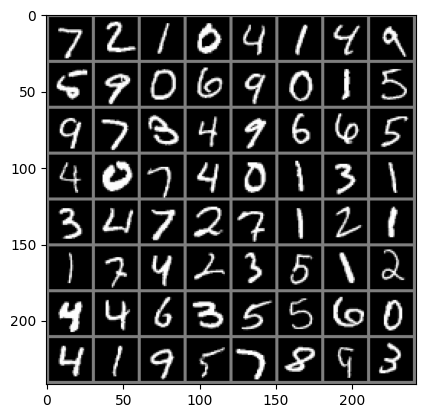

Predicted: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1 3 1 3 4 7 2 7
 1 2 1 1 7 4 2 3 5 1 2 4 4 6 3 5 5 6 0 4 1 9 5 7 8 9 3]
Actual:    [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1 3 1 3 4 7 2 7
 1 2 1 1 7 4 2 3 5 1 2 4 4 6 3 5 5 6 0 4 1 9 5 7 8 9 3]


In [ ]:
import numpy as np

def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap="gray")
    plt.show()

# Get a batch of test images
images, labels = next(iter(test_loader))

# Display images
imshow(torchvision.utils.make_grid(images))

# Get model predictions
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Print predictions
print("Predicted:", predicted.numpy())
print("Actual:   ", labels.numpy())


In [ ]:
# Save the trained model
torch.save(model.state_dict(), "mnist_model.pth")

# Load the model
model = NeuralNet()
model.load_state_dict(torch.load("mnist_model.pth"))
model.eval()  # Set to evaluation mode


<ipython-input-23-29adde8aaf93>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("mnist_model.pth"))


NeuralNet(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)